# Can the Model Beat the Market?
### ECON 148 — Data Science for Economics

All semester we've been asking: **can ML beat econometrics?**

In this notebook we ask the same question in a domain where the answer has real stakes — financial markets. We'll:

1. Pull live price data and understand what we're looking at
2. Fit an **ARIMA** model and generate forecasts
3. Turn those forecasts into a **trading strategy** and backtest it
4. Do the same with **XGBoost** and **Prophet**
5. Compare all three against a simple buy-and-hold benchmark

By the end, you'll have a single chart that shows — honestly — whether any of these models can beat doing nothing.

---
> **Extension:** A fourth model, **Chronos-2** (Amazon's time series foundation model), is included at the end of this notebook. It requires PyTorch and takes a few minutes to install on DataHub, so treat it as optional.

## 0. Setup

Install and import everything we need. Run this cell first.

In [7]:
# Install dependencies (safe to rerun)
#import sys
#!{sys.executable} -m pip install yfinance statsmodels xgboost prophet anthropic --quiet
!pip install yfinance xgboost anthropic -q

In [ ]:
try:
    from dotenv import load_dotenv
except ImportError:
    import sys
    !{sys.executable} -m pip install python-dotenv
    from dotenv import load_dotenv

In [8]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import date, timedelta

import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import xgboost as xgb
from prophet import Prophet
import anthropic 

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor':   '#ffffff',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})

print('All imports successful.')

All imports successful.


---
## 1. Get the Data

We'll use `yfinance` to pull daily adjusted close prices. Change `TICKER` to any symbol you like — stocks, ETFs, crypto (e.g. `BTC-USD`), commodities (e.g. `GLD`).

In [10]:
# ── Configuration ─────────────────────────────────────────
TICKER     = 'AAPL'          # Change me!
START_DATE = '2021-01-01'
END_DATE   = '2025-12-31'
TEST_FRAC  = 0.20            # Hold out last 20% for backtesting
# ──────────────────────────────────────────────────────────

raw = yf.download(TICKER, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)

# Flatten multi-level columns if present
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

prices = raw[['Open','High','Low','Close','Volume']].dropna()

print(f'Ticker   : {TICKER}')
print(f'Rows     : {len(prices):,} trading days')
print(f'From     : {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Latest   : ${prices["Close"].iloc[-1]:.2f}')
prices.tail(3)

Ticker   : AAPL
Rows     : 1,254 trading days
From     : 2021-01-04 → 2025-12-30
Latest   : $272.82


Price,Open,High,Low,Close,Volume
Date,,,,,
2025-12-26,273.903708,275.112569,272.604905,273.144409,21521800
2025-12-29,272.435082,274.103504,272.095404,273.504089,23715200
2025-12-30,272.554970,273.823772,272.025467,272.824707,22139600


In [11]:
# Train / test split
split_idx  = int(len(prices) * (1 - TEST_FRAC))
train      = prices.iloc[:split_idx]
test       = prices.iloc[split_idx:]
split_date = test.index[0].date()

print(f'Train: {len(train)} days  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test : {len(test)} days  ({test.index[0].date()} → {test.index[-1].date()})')
print(f'Split date: {split_date}')

Train: 1003 days  (2021-01-04 → 2024-12-27)
Test : 251 days  (2024-12-30 → 2025-12-30)
Split date: 2024-12-30


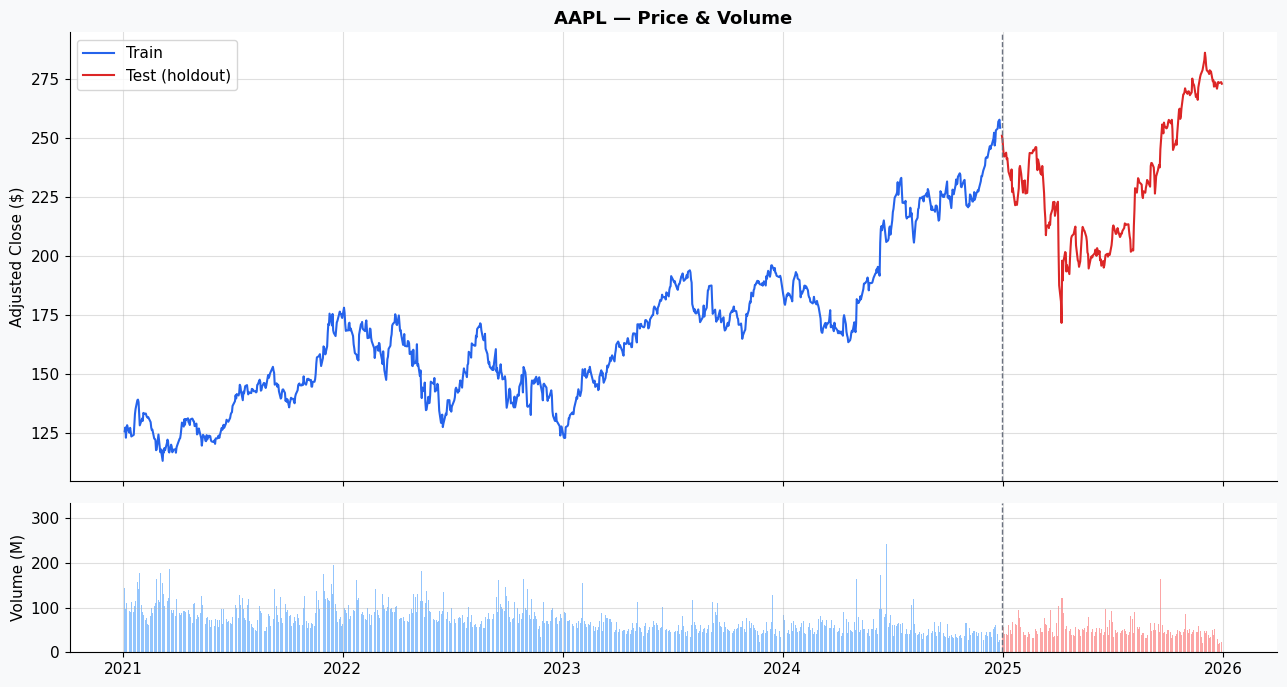

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# Price
axes[0].plot(train.index, train['Close'], color='#2563eb', lw=1.5, label='Train')
axes[0].plot(test.index,  test['Close'],  color='#dc2626', lw=1.5, label='Test (holdout)')
axes[0].axvline(test.index[0], color='#6b7280', ls='--', lw=1)
axes[0].set_ylabel('Adjusted Close ($)')
axes[0].set_title(f'{TICKER} — Price & Volume', fontsize=13, fontweight='bold')
axes[0].legend()

# Volume
axes[1].bar(train.index, train['Volume'] / 1e6, color='#93c5fd', width=1)
axes[1].bar(test.index,  test['Volume']  / 1e6, color='#fca5a5', width=1)
axes[1].axvline(test.index[0], color='#6b7280', ls='--', lw=1)
axes[1].set_ylabel('Volume (M)')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

### Discussion

- The **blue region is what each model will learn from**. The **red region is the holdout** — no model sees it during training.
- Why does this matter? What goes wrong if we train and test on the same data?
- Notice the volume spikes. What events might explain them?

---
## 2. The Backtest Engine

Before fitting any model, let's define the evaluation harness. Every model will pass through the same function — this is how we keep the comparison honest.

**The strategy is simple:** if the model predicts a positive return tomorrow, go long (buy). Otherwise, stay in cash.

Two critical details:
- We **shift the signal by one day** to avoid look-ahead bias. The prediction made on day $t$ is executed at the open of day $t+1$.
- We compare against **buy-and-hold** as our baseline — the strategy that requires zero intelligence.

In [13]:
def backtest(predicted_returns: pd.Series,
             actual_prices:    pd.Series,
             threshold:        float = 0.0) -> dict:
    """
    Convert predicted returns into a long/cash strategy and evaluate it.

    Parameters
    ----------
    predicted_returns : predicted 1-day return for each day in the test set
    actual_prices     : actual closing prices for the same period
    threshold         : minimum predicted return to go long (default 0)

    Returns
    -------
    dict with equity curve, metrics, and buy-and-hold benchmark
    """
    actual_returns = actual_prices.pct_change().fillna(0)

    # Signal: 1 = long, 0 = cash
    signal = (predicted_returns > threshold).astype(int)

    # Shift by 1: prediction on day t executes on day t+1
    signal_lagged = signal.shift(1).fillna(0)

    # Strategy returns
    strat_returns = signal_lagged * actual_returns

    # Equity curves (start at $1)
    equity_strat = (1 + strat_returns).cumprod()
    equity_bnh   = (1 + actual_returns).cumprod()

    # Metrics
    n_days       = len(strat_returns)
    ann_ret      = (equity_strat.iloc[-1] ** (252 / n_days) - 1) * 100
    ann_vol      = strat_returns.std() * np.sqrt(252) * 100
    sharpe       = ann_ret / ann_vol if ann_vol > 0 else 0
    rolling_max  = equity_strat.cummax()
    drawdown     = (equity_strat - rolling_max) / rolling_max
    max_dd       = drawdown.min() * 100
    pct_long     = signal_lagged.mean() * 100

    bnh_ret      = (equity_bnh.iloc[-1] ** (252 / n_days) - 1) * 100

    return {
        'equity':     equity_strat,
        'bnh':        equity_bnh,
        'ann_ret':    ann_ret,
        'ann_vol':    ann_vol,
        'sharpe':     sharpe,
        'max_dd':     max_dd,
        'pct_long':   pct_long,
        'bnh_ret':    bnh_ret,
    }


def print_metrics(name: str, result: dict):
    print(f"\n{'─'*40}")
    print(f"  {name}")
    print(f"{'─'*40}")
    print(f"  Annualized Return : {result['ann_ret']:+.1f}%")
    print(f"  Annualized Vol    : {result['ann_vol']:.1f}%")
    print(f"  Sharpe Ratio      : {result['sharpe']:.2f}")
    print(f"  Max Drawdown      : {result['max_dd']:.1f}%")
    print(f"  % Days Long       : {result['pct_long']:.0f}%")
    print(f"  Buy-and-Hold Ret  : {result['bnh_ret']:+.1f}%  (benchmark)")


print('Backtest engine ready.')

Backtest engine ready.


---
## 3. ARIMA — The Econometrics Baseline

ARIMA (AutoRegressive Integrated Moving Average) is the classical time series model. It assumes the series can be made stationary by differencing, and that future values are a linear function of past values and past errors.

**Parameters:**
- `p` — number of autoregressive lags
- `d` — number of differences needed for stationarity (usually 1 for prices)
- `q` — number of moving average terms

We'll use the ACF and PACF plots to choose `p` and `q`.

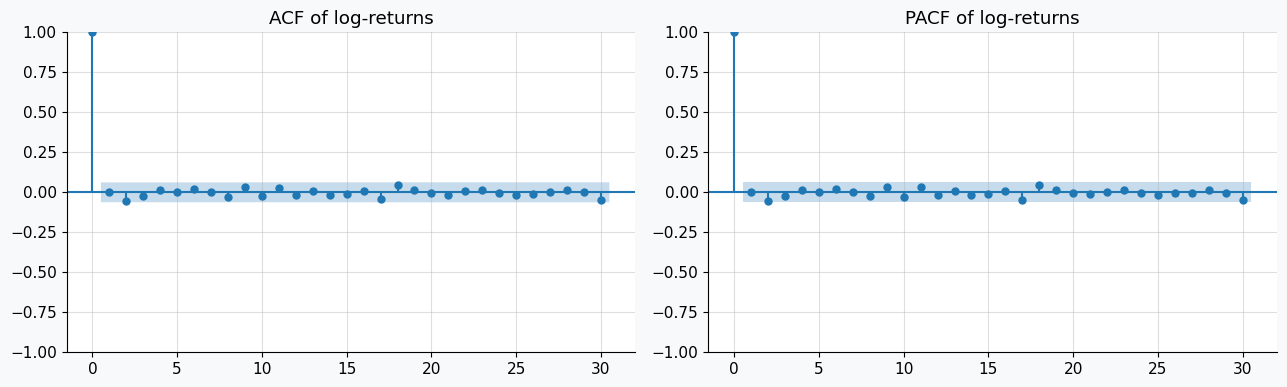

In [14]:
# Work in log-price space (stabilizes variance)
log_close_train = np.log(train['Close'].values)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(np.diff(log_close_train),  lags=30, ax=axes[0], title='ACF of log-returns')
plot_pacf(np.diff(log_close_train), lags=30, ax=axes[1], title='PACF of log-returns')
plt.tight_layout()
plt.show()

**Reading the plots:** Significant spikes in the PACF suggest AR terms (`p`). Significant spikes in the ACF suggest MA terms (`q`). For most stock return series, you'll see very little structure — which is itself informative.

In [15]:
# ── ARIMA parameters ──────────────────────────
P, D, Q = 2, 1, 2   # Try changing these!
# ──────────────────────────────────────────────

log_close_full = np.log(prices['Close'].values)

print(f'Fitting ARIMA({P},{D},{Q}) on training data...')
arima_model = ARIMA(log_close_train, order=(P, D, Q))
arima_fit   = arima_model.fit()
print(arima_fit.summary().tables[0])

Fitting ARIMA(2,1,2) on training data...
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1003
Model:                 ARIMA(2, 1, 2)   Log Likelihood                2677.829
Date:                Thu, 30 Apr 2026   AIC                          -5345.658
Time:                        14:23:29   BIC                          -5321.110
Sample:                             0   HQIC                         -5336.329
                               - 1003                                         
Covariance Type:                  opg                                         


In [16]:
# Generate one-step-ahead forecasts for the test period
# We append each actual test observation and forecast one step ahead
# This simulates what you'd do in practice: refit daily with new data

arima_preds = []
history = list(log_close_train)

log_close_test = np.log(test['Close'].values)

for t in range(len(log_close_test)):
    model = ARIMA(history, order=(P, D, Q))
    fit   = model.fit()
    fc    = fit.forecast(steps=1)[0]
    arima_preds.append(fc)
    history.append(log_close_test[t])   # add actual, not predicted

# Convert log-price forecasts → predicted returns
arima_pred_prices  = np.exp(np.array(arima_preds))
actual_test_prices = test['Close']
arima_pred_returns = pd.Series(
    arima_pred_prices / actual_test_prices.values - 1,
    index=actual_test_prices.index
)

print(f'Generated {len(arima_pred_returns)} one-step-ahead forecasts.')

Generated 251 one-step-ahead forecasts.



────────────────────────────────────────
  ARIMA(2,1,2)
────────────────────────────────────────
  Annualized Return : +3.9%
  Annualized Vol    : 24.7%
  Sharpe Ratio      : 0.16
  Max Drawdown      : -17.6%
  % Days Long       : 46%
  Buy-and-Hold Ret  : +8.8%  (benchmark)


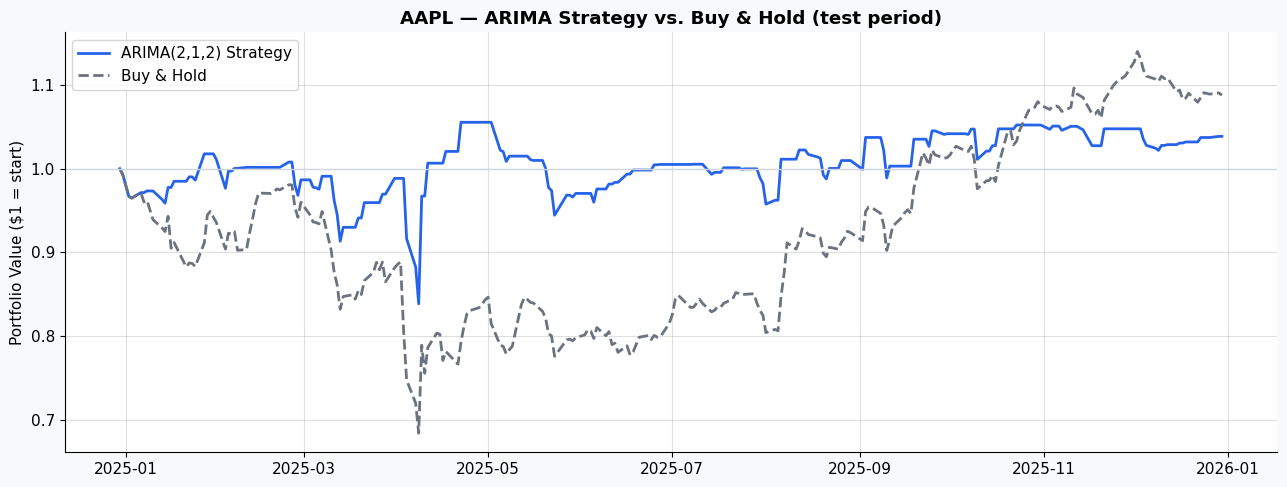

In [17]:
arima_result = backtest(arima_pred_returns, test['Close'])
print_metrics(f'ARIMA({P},{D},{Q})', arima_result)

# Plot
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(arima_result['equity'].index, arima_result['equity'],
        color='#2563eb', lw=2, label=f'ARIMA({P},{D},{Q}) Strategy')
ax.plot(arima_result['bnh'].index, arima_result['bnh'],
        color='#6b7280', lw=2, ls='--', label='Buy & Hold')
ax.axhline(1, color='#d1d5db', lw=1)
ax.set_title(f'{TICKER} — ARIMA Strategy vs. Buy & Hold (test period)', fontweight='bold')
ax.set_ylabel('Portfolio Value ($1 = start)')
ax.legend()
plt.tight_layout()
plt.show()

### Discussion — ARIMA

- Did the ARIMA strategy beat buy-and-hold? By how much?
- What does the **% days long** metric tell you about the model's confidence?
- ARIMA is a **linear model**. What nonlinear patterns in stock prices might it miss?
- We refitted the model every day. Is that realistic? What does it cost in compute? In practice?

---
## 4. XGBoost — The ML Challenger

XGBoost doesn't know anything about time series structure. We have to tell it about the past by **engineering lag features** manually. This is both the power and the danger of ML in finance — you can add any feature you want, but you're making choices about what matters.

**Target:** next day's return (a regression problem)
**Features:** past prices, rolling statistics, volume signals

In [18]:
def make_features(df: pd.DataFrame) -> pd.DataFrame:
    """Engineer lag and rolling features from OHLCV data."""
    X = pd.DataFrame(index=df.index)

    close  = df['Close']
    volume = df['Volume']
    ret    = close.pct_change()

    # Lagged returns
    for lag in [1, 2, 3, 5, 10, 21]:
        X[f'ret_lag{lag}'] = ret.shift(lag)

    # Rolling statistics
    for window in [5, 10, 21]:
        X[f'roll_mean_{window}'] = close.rolling(window).mean() / close - 1
        X[f'roll_std_{window}']  = ret.rolling(window).std()

    # Momentum
    X['mom_1m']  = close / close.shift(21) - 1
    X['mom_3m']  = close / close.shift(63) - 1

    # Volume signal
    X['vol_ratio'] = volume / volume.rolling(21).mean()

    # Calendar
    X['day_of_week'] = pd.to_datetime(df.index).dayofweek

    # Target: next day's return
    X['target'] = ret.shift(-1)

    return X.dropna()


features     = make_features(prices)
feature_cols = [c for c in features.columns if c != 'target']

# Align train/test with feature index
train_feat = features[features.index < test.index[0]]
test_feat  = features[features.index >= test.index[0]]

X_train, y_train = train_feat[feature_cols], train_feat['target']
X_test,  y_test  = test_feat[feature_cols],  test_feat['target']

print(f'Features : {len(feature_cols)}')
print(f'Train    : {len(X_train)} rows')
print(f'Test     : {len(X_test)} rows')
print(f'\nFeature names:\n{feature_cols}')

Features : 16
Train    : 940 rows
Test     : 250 rows

Feature names:
['ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag5', 'ret_lag10', 'ret_lag21', 'roll_mean_5', 'roll_std_5', 'roll_mean_10', 'roll_std_10', 'roll_mean_21', 'roll_std_21', 'mom_1m', 'mom_3m', 'vol_ratio', 'day_of_week']


In [19]:
xgb_model = xgb.XGBRegressor(
    n_estimators   = 300,
    max_depth      = 4,
    learning_rate  = 0.05,
    subsample      = 0.8,
    colsample_bytree = 0.8,
    random_state   = 42,
    verbosity      = 0,
)

xgb_model.fit(X_train, y_train)

xgb_pred_returns = pd.Series(
    xgb_model.predict(X_test),
    index=X_test.index
)

print('XGBoost fitted.')

XGBoost fitted.



────────────────────────────────────────
  XGBoost
────────────────────────────────────────
  Annualized Return : +26.9%
  Annualized Vol    : 26.4%
  Sharpe Ratio      : 1.02
  Max Drawdown      : -16.9%
  % Days Long       : 55%
  Buy-and-Hold Ret  : +9.1%  (benchmark)


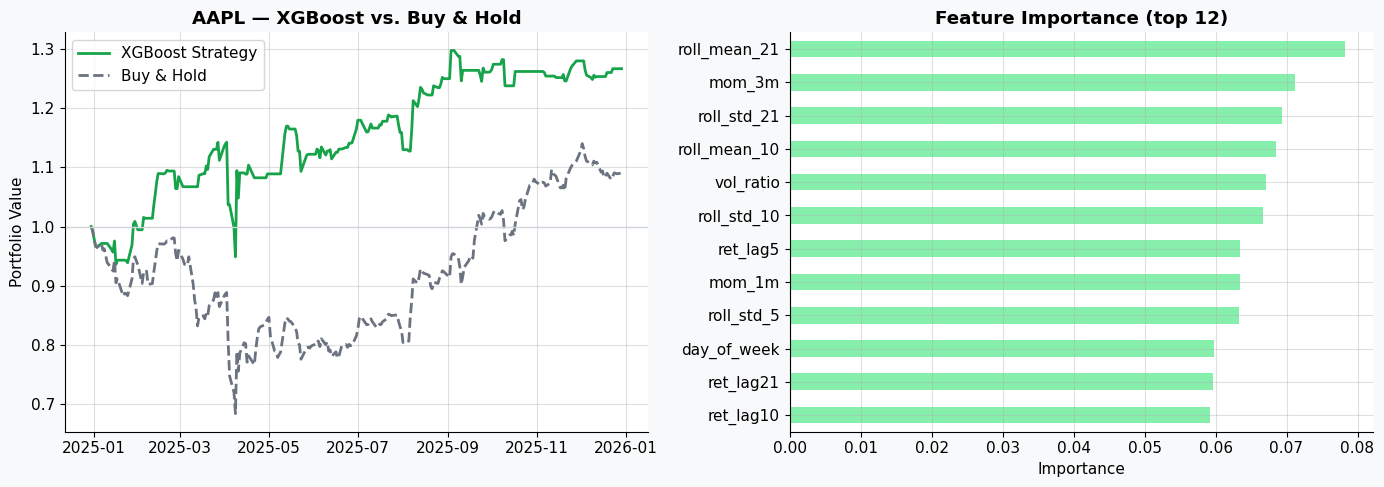

In [20]:
# Align test prices with the feature-available test rows
test_prices_xgb = prices.loc[X_test.index, 'Close']

xgb_result = backtest(xgb_pred_returns, test_prices_xgb)
print_metrics('XGBoost', xgb_result)

# Feature importance
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True).tail(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(xgb_result['equity'].index, xgb_result['equity'],
             color='#16a34a', lw=2, label='XGBoost Strategy')
axes[0].plot(xgb_result['bnh'].index, xgb_result['bnh'],
             color='#6b7280', lw=2, ls='--', label='Buy & Hold')
axes[0].axhline(1, color='#d1d5db', lw=1)
axes[0].set_title(f'{TICKER} — XGBoost vs. Buy & Hold', fontweight='bold')
axes[0].set_ylabel('Portfolio Value')
axes[0].legend()

importance.plot(kind='barh', ax=axes[1], color='#86efac')
axes[1].set_title('Feature Importance (top 12)', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

### Discussion — XGBoost

- Which features does the model rely on most? Does that make economic sense?
- We trained on one stock and tested on the same stock's future. How is this different from training on a cross-section of stocks?
- XGBoost has no concept of time order — features from day $t$ could theoretically include data from day $t+5$ if we're not careful. Look at `make_features()`: are we leak-free?
- If you add 50 more features, what happens? What would an econometrician say about that?

---
## 5. Prophet — The Business Analyst's Model

Prophet was built by Facebook/Meta for forecasting business time series — ad revenue, user counts, things with strong weekly and yearly seasonality. It decomposes the series into trend + seasonality + holidays and fits them separately.

Stock prices have no weekly seasonality to speak of — markets are closed on weekends, and returns on Mondays aren't systematically different from Wednesdays. This is an assumption mismatch, and that's the point. Let's see what happens anyway.

In [21]:
# Prophet requires columns named 'ds' (date) and 'y' (value)
prophet_train = pd.DataFrame({
    'ds': train.index,
    'y':  np.log(train['Close'].values)   # log-price
})

prophet_model = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = False,   # turn off — markets have no weekly pattern
    daily_seasonality   = False,
    changepoint_prior_scale = 0.05,
)

prophet_model.fit(prophet_train)
print('Prophet fitted.')

14:28:06 - cmdstanpy - INFO - Chain [1] start processing
14:28:07 - cmdstanpy - INFO - Chain [1] done processing


Prophet fitted.



────────────────────────────────────────
  Prophet
────────────────────────────────────────
  Annualized Return : +13.8%
  Annualized Vol    : 32.3%
  Sharpe Ratio      : 0.43
  Max Drawdown      : -30.2%
  % Days Long       : 98%
  Buy-and-Hold Ret  : +8.8%  (benchmark)


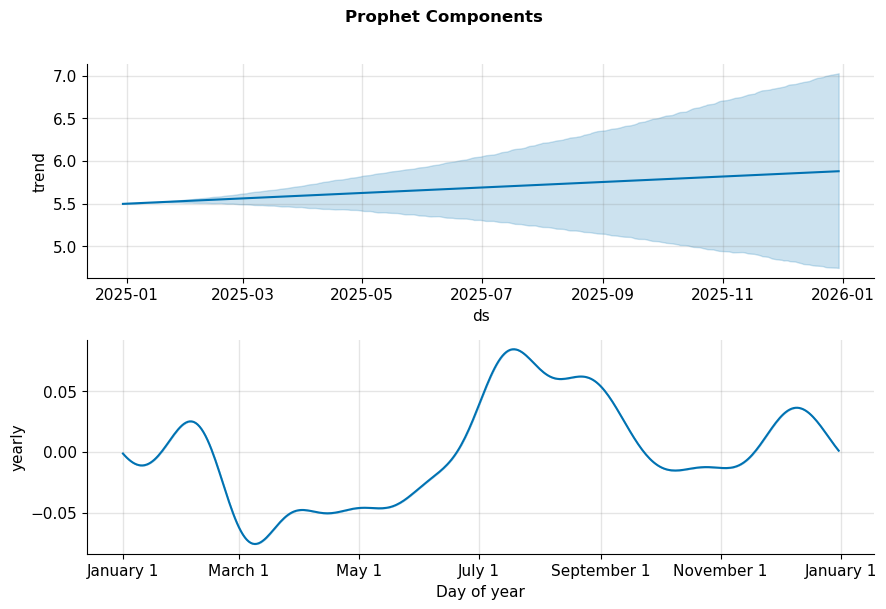

In [22]:
# Forecast the test period
future = pd.DataFrame({'ds': test.index})
prophet_fc = prophet_model.predict(future)

# Convert log-price forecast → predicted returns
prophet_pred_prices  = np.exp(prophet_fc['yhat'].values)
prophet_pred_returns = pd.Series(
    prophet_pred_prices / test['Close'].values - 1,
    index=test.index
)

prophet_result = backtest(prophet_pred_returns, test['Close'])
print_metrics('Prophet', prophet_result)

# Plot components
fig = prophet_model.plot_components(prophet_fc)
fig.suptitle('Prophet Components', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

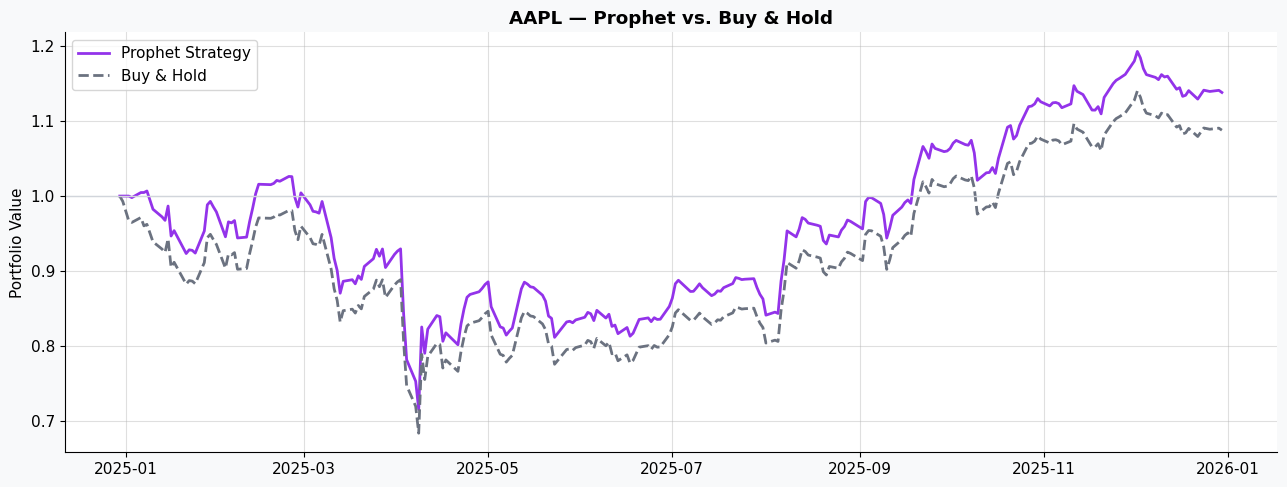

In [23]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(prophet_result['equity'].index, prophet_result['equity'],
        color='#9333ea', lw=2, label='Prophet Strategy')
ax.plot(prophet_result['bnh'].index, prophet_result['bnh'],
        color='#6b7280', lw=2, ls='--', label='Buy & Hold')
ax.axhline(1, color='#d1d5db', lw=1)
ax.set_title(f'{TICKER} — Prophet vs. Buy & Hold', fontweight='bold')
ax.set_ylabel('Portfolio Value')
ax.legend()
plt.tight_layout()
plt.show()

### Discussion — Prophet

- Look at the trend and yearly components. Do they make intuitive sense?
- Prophet assumes the future will look structurally similar to the past. When does that break down?
- We turned off weekly seasonality. What would happen if we left it on?
- How is Prophet different from ARIMA in its assumptions? Which assumptions are more defensible for financial data?

---
## 6. The Grand Comparison

All three models, same holdout period, same trading rule, same benchmark.

In [24]:
results = {
    f'ARIMA({P},{D},{Q})': arima_result,
    'XGBoost':             xgb_result,
    'Prophet':             prophet_result,
}

colors = {
    f'ARIMA({P},{D},{Q})': '#2563eb',
    'XGBoost':             '#16a34a',
    'Prophet':             '#9333ea',
}

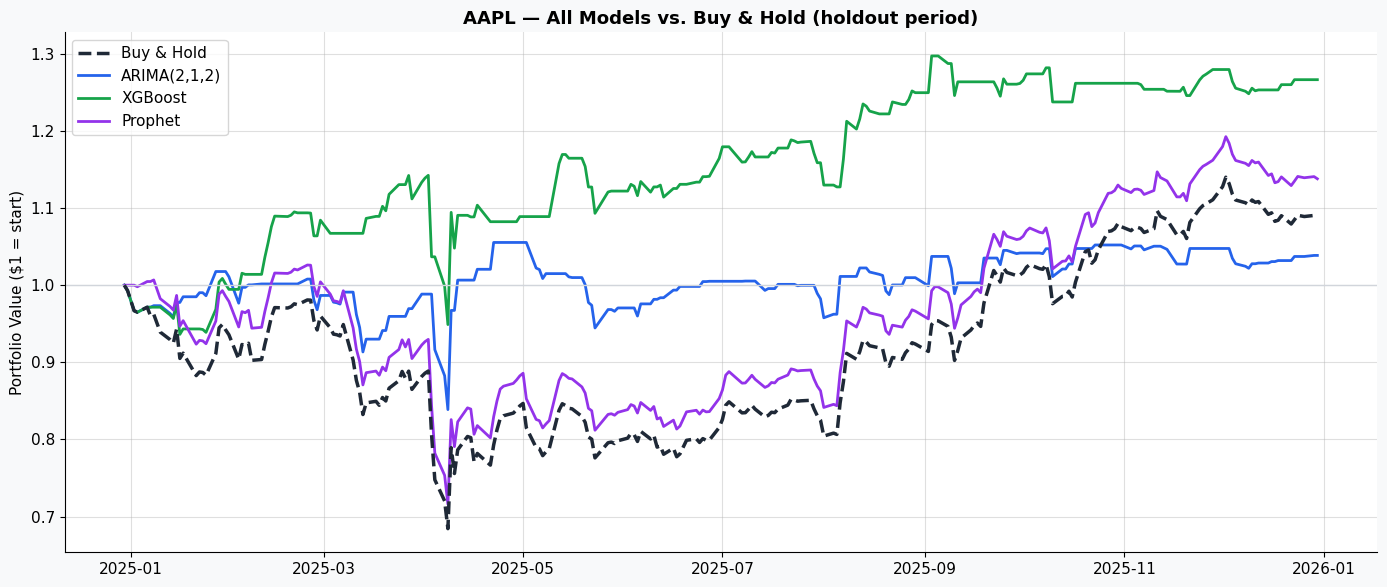

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))

# Buy-and-hold (use first result's bnh since it's the same market)
first_result = next(iter(results.values()))
ax.plot(first_result['bnh'].index, first_result['bnh'],
        color='#1f2937', lw=2.5, ls='--', zorder=10, label='Buy & Hold')

for name, res in results.items():
    # Reindex to common test period
    eq = res['equity'].reindex(first_result['bnh'].index, method='ffill')
    ax.plot(eq.index, eq, color=colors[name], lw=2, label=name)

ax.axhline(1, color='#d1d5db', lw=1)
ax.set_title(f'{TICKER} — All Models vs. Buy & Hold (holdout period)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Portfolio Value ($1 = start)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [26]:
# Summary table
summary_rows = []
for name, res in results.items():
    summary_rows.append({
        'Model':          name,
        'Ann. Return (%)':f"{res['ann_ret']:+.1f}",
        'Ann. Vol (%)':   f"{res['ann_vol']:.1f}",
        'Sharpe':         f"{res['sharpe']:.2f}",
        'Max Drawdown (%)':f"{res['max_dd']:.1f}",
        '% Days Long':    f"{res['pct_long']:.0f}%",
    })

# Add buy-and-hold
bnh_ann = first_result['bnh_ret']
summary_rows.append({
    'Model':           'Buy & Hold',
    'Ann. Return (%)': f"{bnh_ann:+.1f}",
    'Ann. Vol (%)':    '—',
    'Sharpe':          '—',
    'Max Drawdown (%)':'—',
    '% Days Long':     '100%',
})

summary = pd.DataFrame(summary_rows).set_index('Model')
summary

,Ann. Return (%),Ann. Vol (%),Sharpe,Max Drawdown (%),% Days Long
Model,,,,,
"ARIMA(2,1,2)",+3.9,24.7,0.16,-17.6,46%
XGBoost,+26.9,26.4,1.02,-16.9,55%
Prophet,+13.8,32.3,0.43,-30.2,98%
Buy & Hold,+8.8,—,—,—,100%


### The Big Discussion

**On the results:**
- Did any model consistently beat buy-and-hold? Is that surprising?
- The Efficient Market Hypothesis says this should be hard. Do your results support or contradict it?
- Which model would you trust most, and why — not based on performance, but based on its assumptions?

**On the methodology:**
- We used one ticker and one time period. How would you test whether your results generalize?
- We ignored transaction costs (bid-ask spread, commissions). A strategy that trades every day will bleed a lot of that. How would you estimate this?
- We picked the ticker and date range before looking at results. What if we hadn't?

**The causal inference question:**
- We're doing prediction, not causal inference. Is that okay? What would a causal question even look like here?
- If XGBoost finds that `mom_1m` (one-month momentum) is the top feature — does that mean momentum *causes* future returns? What would you need to establish that?

> **The uncomfortable truth:** A quant fund with 50 PhDs, microsecond execution, and co-location at the exchange is competing against you for the same edge. The moment a signal becomes public knowledge, it tends to get arbitraged away. That's survivorship bias at the strategy level.

---
## 7. Ask Claude

Let's send our backtest results to Claude and ask it to play quant analyst — interpreting the numbers, flagging the methodology problems, and asking the class a hard question.

Set your `ANTHROPIC_API_KEY` in the environment, or paste it in the cell below.

In [34]:
import os

In [42]:
env_file_path = "/home/jovyan/_shared/bcourses-1551764-readonly/.env"
load_dotenv(env_file_path)
api_key = os.getenv('ANTHROPIC_API_KEY')

print("API Key loaded:", "✅ Ready" if anthropic_api_key else "❌ Not found — check your .env file")

API Key loaded: ✅ Ready


In [43]:

from anthropic import Anthropic
# os.environ['ANTHROPIC_API_KEY'] = 'sk-ant-...'  # uncomment and paste if needed
claude = Anthropic(api_key=api_key)

# Build a results summary string
rows = []
for name, res in results.items():
    rows.append(f"  {name}: return={res['ann_ret']:+.1f}%, sharpe={res['sharpe']:.2f}, "
                f"max_drawdown={res['max_dd']:.1f}%, pct_long={res['pct_long']:.0f}%")
rows.append(f"  Buy & Hold: return={first_result['bnh_ret']:+.1f}%")
results_text = '\n'.join(rows)

prompt = f"""You are a sharp, skeptical quantitative analyst talking to a room of economics students
who have spent a semester on causal inference, time series forecasting, and ML vs. econometrics.

Here are backtesting results for {TICKER} over the holdout period {split_date} to {test.index[-1].date()}:

{results_text}

Models:
- ARIMA: classical econometric time series model
- XGBoost: gradient boosting with engineered lag/rolling features
- Prophet: Facebook's decomposition model with trend + yearly seasonality
- All strategies: go long if model predicts positive return, else hold cash

Please:
1. Give a sharp one-paragraph interpretation of the results — what stands out, what is suspicious.
2. Name the two biggest methodological problems with this backtest.
3. Pose one hard question for the class about causation vs. prediction in financial markets.

Be direct. No disclaimers. You're in a classroom."""

response = claude.messages.create(
    model='claude-sonnet-4-20250514',
    max_tokens=800,
    messages=[{'role': 'user', 'content': prompt}]
)

print('── Claude says ─────────────────────────────────────────────────────────')
print(response.content[0].text)

── Claude says ─────────────────────────────────────────────────────────
**Results Interpretation:**
XGBoost crushed it with a 1.02 Sharpe and 27% returns, which should immediately make you suspicious—this screams overfitting to recent market patterns that won't persist. Prophet's 98% long exposure tells you it's basically a leveraged buy-and-hold strategy disguised as forecasting, riding the trend with massive drawdowns when wrong. ARIMA barely beat cash despite being the theoretically sound approach, which is typical—econometric models that respect market efficiency get mediocre returns while black-box ML models that exploit spurious correlations look brilliant until they don't.

**Two Biggest Methodological Problems:**
1. **Lookahead bias in feature engineering** - XGBoost likely used future information in creating rolling features or the entire feature set was optimized on data that includes the test period
2. **No out-of-sample parameter selection** - These models were almost cert

---
## 8. Cross-Sectional Test — The Magnificent Seven

One backtest on one stock proves nothing. The real question is whether a model generalizes.

We'll run XGBoost and Prophet against buy-and-hold across all seven mega-cap tech stocks — same training window, same holdout period, same trading rule. If XGBoost only wins on AAPL, that tells you something very specific: it didn't learn a generalizable signal, it learned AAPL's 2020–2023 personality.

> **Note:** This cell takes 3–5 minutes to run — Prophet is being fit 7 times. Grab a coffee.

In [44]:
MAG7 = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA']

# Reuse make_features and backtest from earlier in the notebook
from prophet import Prophet

def run_xgb(train_, test_):
    """Fit XGBoost on train_, predict on test_, return predicted returns."""
    feat_all   = make_features(pd.concat([train_, test_]))
    feat_cols  = [c for c in feat_all.columns if c != 'target']
    train_feat = feat_all[feat_all.index < test_.index[0]]
    test_feat  = feat_all[feat_all.index >= test_.index[0]]

    model = xgb.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0
    )
    model.fit(train_feat[feat_cols], train_feat['target'])
    preds = pd.Series(model.predict(test_feat[feat_cols]), index=test_feat.index)
    prices_aligned = test_.loc[test_feat.index, 'Close']
    return preds, prices_aligned


def run_prophet(train_, test_):
    """Fit Prophet on train_, forecast test period, return predicted returns."""
    df_train = pd.DataFrame({
        'ds': train_.index,
        'y':  np.log(train_['Close'].values)
    })
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                daily_seasonality=False, changepoint_prior_scale=0.05)
    m.fit(df_train)
    future = pd.DataFrame({'ds': test_.index})
    fc     = m.predict(future)
    pred_prices   = np.exp(fc['yhat'].values)
    pred_returns  = pd.Series(pred_prices / test_['Close'].values - 1, index=test_.index)
    return pred_returns, test_['Close']


records = []

for ticker in MAG7:
    print(f'Running {ticker}...', end=' ')
    try:
        raw_ = yf.download(ticker, start=START_DATE, end=END_DATE,
                           auto_adjust=True, progress=False)
        if isinstance(raw_.columns, pd.MultiIndex):
            raw_.columns = raw_.columns.get_level_values(0)
        p_  = raw_[['Open','High','Low','Close','Volume']].dropna()
        sp_ = int(len(p_) * (1 - TEST_FRAC))
        tr_ = p_.iloc[:sp_]
        te_ = p_.iloc[sp_:]

        # XGBoost
        xgb_preds, xgb_prices = run_xgb(tr_, te_)
        xgb_res = backtest(xgb_preds, xgb_prices)

        # Prophet
        proph_preds, proph_prices = run_prophet(tr_, te_)
        proph_res = backtest(proph_preds, proph_prices)

        # Buy-and-hold (same test period)
        bnh_ret = xgb_res['bnh_ret']

        records.append({
            'Ticker':         ticker,
            'XGBoost':        round(xgb_res['ann_ret'],   1),
            'XGB Sharpe':     round(xgb_res['sharpe'],    2),
            'Prophet':        round(proph_res['ann_ret'],  1),
            'Prophet Sharpe': round(proph_res['sharpe'],   2),
            'Buy & Hold':     round(bnh_ret,               1),
        })
        print('done')
    except Exception as e:
        print(f'ERROR: {e}')

mag7_df = pd.DataFrame(records).set_index('Ticker')
print('\nAll done.')

Running AAPL... 

14:38:32 - cmdstanpy - INFO - Chain [1] start processing
14:38:33 - cmdstanpy - INFO - Chain [1] done processing


done
Running MSFT... 

14:38:34 - cmdstanpy - INFO - Chain [1] start processing
14:38:34 - cmdstanpy - INFO - Chain [1] done processing


done
Running GOOGL... 

...

done
Running NVDA... 

14:38:47 - cmdstanpy - INFO - Chain [1] start processing
14:38:48 - cmdstanpy - INFO - Chain [1] done processing


done
Running TSLA... 

14:38:50 - cmdstanpy - INFO - Chain [1] start processing
14:38:51 - cmdstanpy - INFO - Chain [1] done processing


done

All done.


In [45]:
# ── Results table ─────────────────────────────────────────────────────────
def highlight_vs_bnh(row):
    """Color XGBoost and Prophet cells green if they beat buy-and-hold."""
    bnh = row['Buy & Hold']
    styles = []
    for col in row.index:
        if col in ('XGBoost', 'Prophet'):
            color = '#d1fae5' if row[col] > bnh else '#fee2e2'
            styles.append(f'background-color: {color}')
        else:
            styles.append('')
    return styles

mag7_df.style.apply(highlight_vs_bnh, axis=1).format({
    'XGBoost':        '{:+.1f}%',
    'XGB Sharpe':     '{:.2f}',
    'Prophet':        '{:+.1f}%',
    'Prophet Sharpe': '{:.2f}',
    'Buy & Hold':     '{:+.1f}%',
})

,XGBoost,XGB Sharpe,Prophet,Prophet Sharpe,Buy & Hold
Ticker,,,,,
AAPL,+26.9%,1.02,+13.8%,0.43,+9.1%
MSFT,+12.2%,0.61,+14.5%,0.72,+15.6%
GOOGL,+39.3%,1.62,+45.0%,1.52,+65.3%
AMZN,+32.6%,1.29,+3.5%,0.10,+4.9%
META,+22.2%,0.88,+26.2%,0.70,+11.9%
NVDA,+48.6%,1.31,+40.8%,0.83,+37.3%
TSLA,+27.1%,0.51,+22.3%,0.37,+10.2%


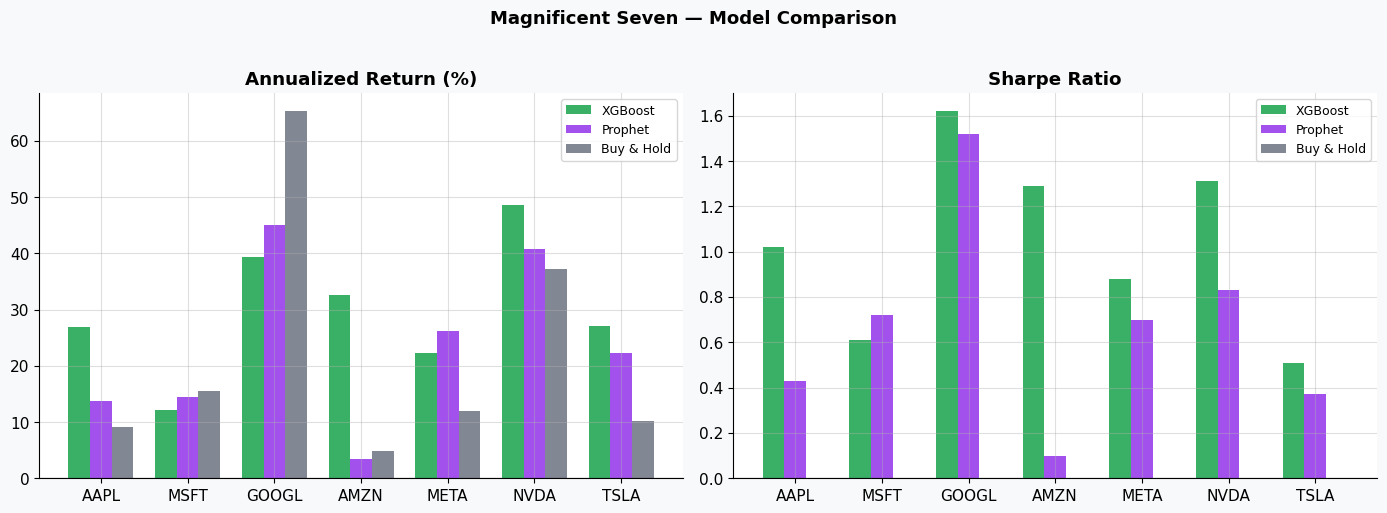

In [46]:
# ── Visual comparison ─────────────────────────────────────────────────────
x      = np.arange(len(MAG7))
width  = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in [
    (axes[0], 'ann_ret', 'Annualized Return (%)'),
    (axes[1], 'sharpe',  'Sharpe Ratio'),
]:
    bnh_vals   = mag7_df['Buy & Hold'].values if metric == 'ann_ret' else np.zeros(len(MAG7))
    xgb_vals   = mag7_df['XGBoost'].values    if metric == 'ann_ret' else mag7_df['XGB Sharpe'].values
    proph_vals = mag7_df['Prophet'].values     if metric == 'ann_ret' else mag7_df['Prophet Sharpe'].values

    ax.bar(x - width, xgb_vals,   width, label='XGBoost', color='#16a34a', alpha=0.85)
    ax.bar(x,         proph_vals,  width, label='Prophet', color='#9333ea', alpha=0.85)
    ax.bar(x + width, bnh_vals,    width, label='Buy & Hold', color='#6b7280', alpha=0.85)
    ax.axhline(0, color='#374151', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(MAG7)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Magnificent Seven — Model Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Discussion — Cross-Sectional Results

**On generalization:**
- How many tickers did XGBoost beat buy-and-hold on? Is that more or less than you'd expect by chance?
- If a model beats buy-and-hold on 4 out of 7 stocks, is that evidence the model works? What's the null hypothesis?
- TSLA and NVDA have dramatically higher volatility than MSFT and GOOGL. Does that affect how you interpret the Sharpe ratios?

**On overfitting:**
- XGBoost was trained separately on each stock. That means it fit 7 different models. Is that one model or seven? What does that imply about generalization?
- What would it look like to train one XGBoost model on all seven stocks simultaneously and test it on each? How would that change the interpretation?

**The punchline:**
> A model that beats buy-and-hold on 4 of 7 Mag 7 stocks in a 4-year bull market is not a model you should trust with real money. You've been given 7 chances to get lucky. The Efficient Market Hypothesis predicts roughly this outcome.

---
## Extension: Chronos-2 — The Foundation Model

> **DataHub note:** Chronos requires `torch` and `chronos-forecasting`. `torch` CPU-only is ~200MB (use the index-url install below). If you're on a machine with a GPU (or patient on CPU), uncomment the install cell and proceed.

Chronos is Amazon's time series foundation model — pretrained on millions of time series from the web, including financial data. Unlike ARIMA, XGBoost, and Prophet, you give it no parameters and no feature engineering. You just hand it the series and ask for a forecast.

This raises the question we can't fully answer: **what did it learn, and from where?** If it was pretrained on AAPL data from 2015–2022, and we're testing on 2023–2024, is that really out-of-sample?

In [47]:
# Uncomment to install (may take 5+ minutes on DataHub)
# CPU-only torch (~200MB vs ~2GB with CUDA — use this on DataHub)
!pip install torch --index-url https://download.pytorch.org/whl/cpu --quiet
!pip install git+https://github.com/amazon-science/chronos-forecasting.git --quiet


Uncomment the lines above to install Chronos dependencies.


In [54]:
base = '/home/jovyan/_shared/bcourses-1551764-readonly/models'

for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 4:  # don't go too deep
        for f in files[:3]:
            print(f'{indent}  {f}')


models/
  CACHEDIR.TAG
  models--amazon--chronos-t5-small/
    refs/
      main
    snapshots/
      a971ba21945c4f1796b17a91fe69214b5f4ad472/
        model.safetensors
        .gitattributes
        README.md
        figures/
    blobs/
      9c8b6fde5300f72b01c173153bf9288fa0a200614275bf0585071ad71a6a3d43
      b9ce8d0e4e0eee976236d60380470d74b210328b
      7528dbb1b6ce860d242aff71294a5fef12a41572
  xet/
    https___cas_serv-tGqkUaZf_CBPHQ6h/
      staging/
    logs/
      xet_20260430T144323126-0700_564.log
  .locks/
    models--amazon--chronos-t5-small/


In [55]:
import os
import torch
from chronos import ChronosPipeline

SNAPSHOT_PATH = '/home/jovyan/_shared/bcourses-1551764-readonly/models/models--amazon--chronos-t5-small/snapshots/a971ba21945c4f1796b17a91fe69214b5f4ad472'

pipeline = ChronosPipeline.from_pretrained(
    SNAPSHOT_PATH,
    device_map='cpu',
    torch_dtype=torch.float32,
    local_files_only=True,
)

print('Chronos loaded.')

`torch_dtype` is deprecated! Use `dtype` instead!


Chronos loaded.


Generating 251 one-step forecasts with Chronos...

────────────────────────────────────────
  Chronos-2 (small)
────────────────────────────────────────
  Annualized Return : -13.2%
  Annualized Vol    : 26.5%
  Sharpe Ratio      : -0.50
  Max Drawdown      : -28.3%
  % Days Long       : 53%
  Buy-and-Hold Ret  : +8.8%  (benchmark)


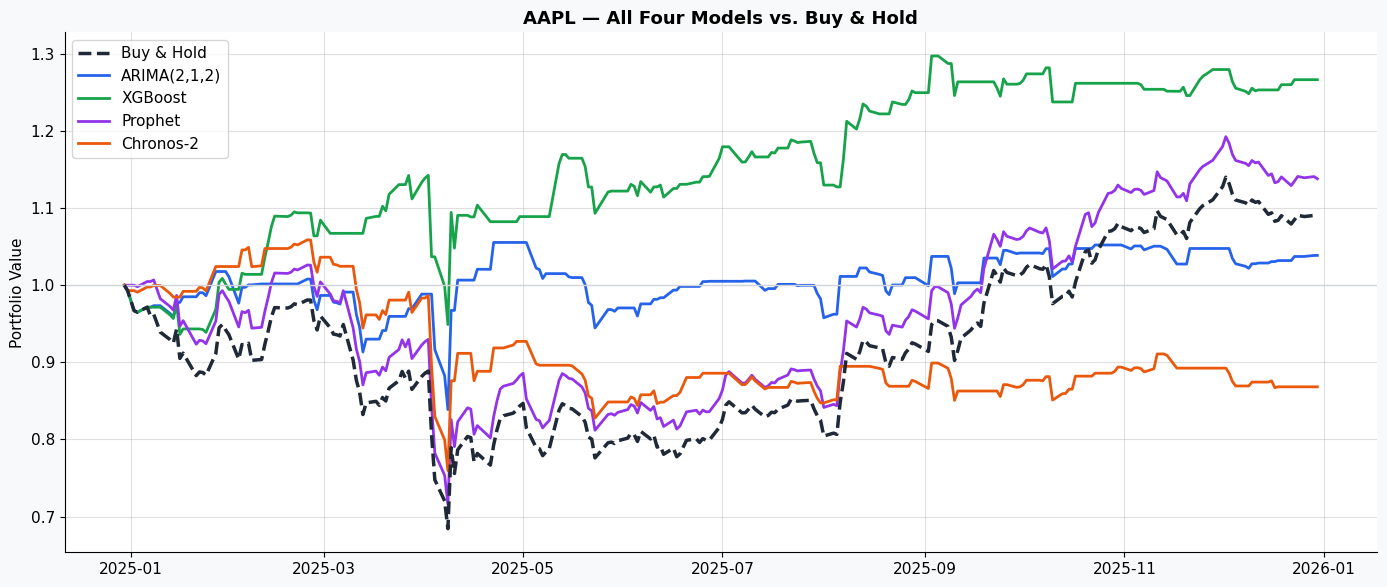

In [57]:

# Walk-forward: one-step forecasts over the test period
CHRONOS_HORIZON = 1
chronos_preds   = []
history_vals    = list(np.log(train['Close'].values))

print(f'Generating {len(test)} one-step forecasts with Chronos...')
for t in range(len(test)):
    ctx = torch.tensor(history_vals, dtype=torch.float32).unsqueeze(0)
    forecast = pipeline.predict(
    ctx,                              # positional, not keyword
    prediction_length=CHRONOS_HORIZON,
    num_samples=20,
)
    median_fc = forecast[0].median(dim=0).values.item()
    chronos_preds.append(np.exp(median_fc))
    history_vals.append(np.log(test['Close'].iloc[t]))

chronos_pred_returns = pd.Series(
    np.array(chronos_preds) / test['Close'].values - 1,
    index=test.index
)

chronos_result = backtest(chronos_pred_returns, test['Close'])
print_metrics('Chronos-2 (small)', chronos_result)

# Add to comparison chart
all_results = dict(**results, **{'Chronos-2': chronos_result})
all_colors  = dict(**colors,  **{'Chronos-2': '#ea580c'})

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(first_result['bnh'].index, first_result['bnh'],
        color='#1f2937', lw=2.5, ls='--', zorder=10, label='Buy & Hold')
for name, res in all_results.items():
    eq = res['equity'].reindex(first_result['bnh'].index, method='ffill')
    ax.plot(eq.index, eq, color=all_colors[name], lw=2, label=name)
ax.axhline(1, color='#d1d5db', lw=1)
ax.set_title(f'{TICKER} — All Four Models vs. Buy & Hold', fontsize=13, fontweight='bold')
ax.set_ylabel('Portfolio Value')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Discussion — Chronos

- Chronos required zero feature engineering and zero parameter selection. Is that a feature or a bug?
- Foundation models are pretrained on internet-scale data. **What does that mean for the notion of out-of-sample testing?** If the model saw AAPL data during pretraining, is our holdout period truly unseen?
- Chronos outputs a **distribution** over forecasts (we took the median). How would you use the full distribution in a trading strategy? Does uncertainty matter to an investor?
- Compare the compute required for each model. ARIMA: seconds. XGBoost: seconds. Prophet: seconds. Chronos: minutes on CPU, seconds on GPU. Is the performance improvement (if any) worth the cost?

---

